  Vehicle_Type  Vehicle_Age  Mileage  Engine_Temp   RPM  Oil_Pressure  \
0    Hatchback           10     7984           85  1144            36   
1        Sedan            5   132389           86  1660            34   
2          SUV           10   158617          101  2588            26   
3          SUV            5    54477           99  2762            39   
4        Sedan            3   122035          102  2146            41   

   Fuel_Consumption  Battery_Voltage  Brake_Pressure  Tire_Pressure  \
0              19.2            12.65              27             32   
1              14.4            11.90              34             33   
2              10.9            12.43              43             31   
3              10.3            11.89              29             29   
4              13.0            12.09              44             36   

  Tire_Condition Vibration_Level  Last_Service_Months Accident_History  \
0           Good            High                    8       

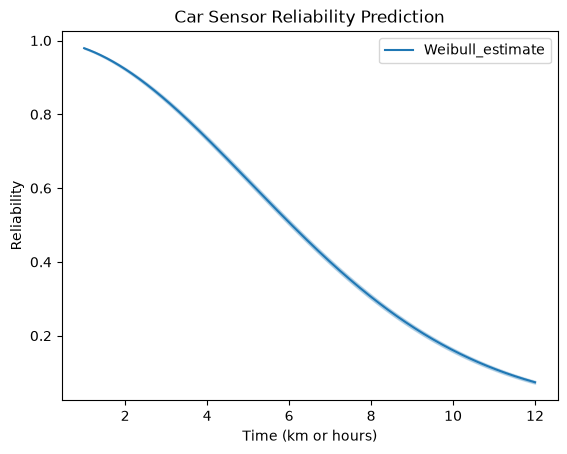

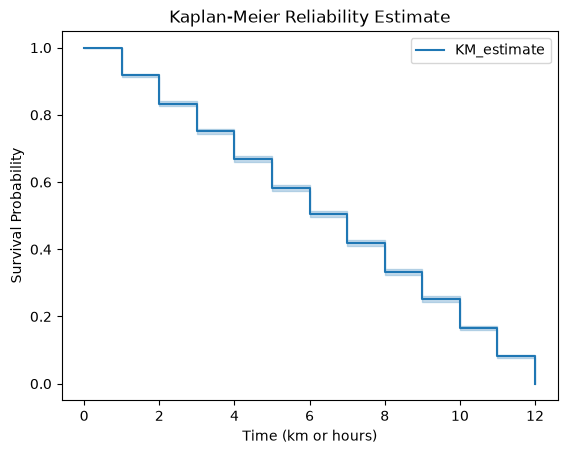

Train shape: (9600, 2) Test shape: (2400, 2)


c:\Users\Akshay\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_forest.py:811: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\Akshay\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\tree\_classes.py:289: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\Akshay\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\tree\_classes.py:289: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\Akshay\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\tree\_classes.py:289:

Accuracy: 0.0
Confusion Matrix:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [12]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import WeibullFitter, KaplanMeierFitter
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Step 2: Load your Excel/CSV field data
df = pd.read_csv("D:\\Personnel\\Certification\\AI ML PG\\Projects python\\Capstone project\\Reliability Prediction\\exactkm.csv")  

# or pd.read_excel("exactkm.xlsx")

# Inspect structure
print(df.head())

# Example assumption: columns like 'sensor_id', 'time_to_failure', 'failed' (1=failed, 0=censored)
# Adjust column names to match your sheet

# Step 3: Reliability modeling (Weibull fit)
wf = WeibullFitter()
wf.fit(df['Vehicle_Age'], event_observed=df['Remaining_KM'])

# Correct attribute names in lifelines
print("Shape parameter (ρ):", wf.rho_)
print("Scale parameter (λ):", wf.lambda_)

# Plot reliability curve
wf.plot_survival_function()
plt.title("Car Sensor Reliability Prediction")
plt.xlabel("Time (km or hours)")
plt.ylabel("Reliability")
plt.show()

# Step 4: Kaplan-Meier non-parametric survival estimate
kmf = KaplanMeierFitter()
kmf.fit(df['Vehicle_Age'], event_observed=df['Remaining_KM'])
kmf.plot_survival_function()
plt.title("Kaplan-Meier Reliability Estimate")
plt.xlabel("Time (km or hours)")
plt.ylabel("Survival Probability")
plt.show()

# Step 5: ML-based prediction (optional)
# Suppose you have sensor features ('Vehicle_Age','Remaining_KM','KM_Range_Before_Defect', etc.)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Clean features
X = df[['Vehicle_Age','KM_Range_Before_Defect']].apply(pd.to_numeric, errors='coerce').fillna(0)
y = df['Remaining_KM'].astype(int)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

